# The Supervisor-as-Tools Pattern — In Depth

## Table of Contents
1. [What Is It?](#what-is-it)
2. [How It Differs From the Standard Supervisor Pattern](#how-it-differs-from-the-standard-supervisor-pattern)
3. [Why Does It Matter?](#why-does-it-matter)
4. [How It Works — Architecture](#how-it-works--architecture)
5. [Comparison With Other Agentic Patterns](#comparison-with-other-agentic-patterns)
6. [Real-World Use Cases](#real-world-use-cases)
7. [Building It From Scratch (LangGraph)](#building-it-from-scratch-langgraph)
8. [Key Takeaways](#key-takeaways)

---

## What Is It?

The **Supervisor-as-Tools** pattern (also known as *Sub-Agents as Tools*) is a multi-agent design pattern where a centralized coordinator agent delegates work to specialized agents by invoking them **directly as tools**. 

Rather than routing control to separate nodes in a graph using conditional edges, the supervisor sees each specialist agent as a function it can call. When the supervisor's LLM determines it needs research, calculations, or writing, it outputs a tool call (e.g. `call_researcher(query="...")`). A tool executor intercepts this call, spins up the specialist agent (which might run its own isolated graph or code), gathers the result, and returns it to the supervisor as a tool message.

```mermaid
flowchart TD
    Start([📥 Input Query]) --> Supervisor["🧠 Supervisor Agent<br/>(LLM + Tools)"]
    Supervisor --> Edge{"⚡ Has Tool Call?"}
    
    Edge -- Yes --> ToolNode["⚙️ Tool Node<br/>(Sub-Agent Library)"]
    
    subgraph Specialist Agents [Executed inside Tool Node]
        ToolNode --> S1["🔍 Research Agent<br/>(Web Search Subgraph)"]
        ToolNode --> S2["✍️ Writing Agent<br/>(Editor Subgraph)"]
    end
    
    S1 --> Join["📝 Merge Output<br/>Return ToolMessage"]
    S2 --> Join
    
    Join --> Supervisor
    
    Edge -- No --> End([📤 Final Response])
    
    style Supervisor fill:#4a9eff,color:#fff
    style ToolNode fill:#e74c3c,color:#fff
    style S1 fill:#3498db,color:#fff
    style S2 fill:#2ecc71,color:#fff
    style Join fill:#f1c40f,color:#000
```

---

## How It Differs From the Standard Supervisor Pattern

While both patterns achieve hierarchical delegation, their routing control and state dynamics are fundamentally different.

```mermaid
graph TD
    subgraph Standard Supervisor Routing Pattern
        SA[Supervisor Node] -- Edge Route --> SB[Specialist Node 1]
        SB -- Edge Route --> SA
    end
    
    subgraph Supervisor-as-Tools Pattern
        TA[Supervisor Node] -- Tool Call --> TB[Tool Node]
        subgraph Tool Node
            TB --> TC[Specialist Function / Graph]
        end
        TC --> TA
    end
```

| Dimension | Standard Supervisor Routing | Supervisor-as-Tools |
| :--- | :--- | :--- |
| **Control Driver** | **Graph Logic**: Managed via conditional edges, routers, or states (`Command(goto="specialist")`). | **LLM Reasoning**: Managed dynamically via tool-calling libraries and execution loops. |
| **Graph Complexity** | **High**: The graph contains separate nodes for every single specialist, leading to star-shaped graphs. | **Low**: The graph only has two main nodes: the `Supervisor` and a generic `ToolNode`. Specialists are hidden inside the tool list. |
| **State sharing** | **Shared**: Often shares a unified conversation history (`MessagesState`) or requires mapping functions to synchronize parent/child states. | **Isolated**: The supervisor passes only explicit arguments to the specialist tool. The specialist's internal search queries or reasoning steps do not bleed into the supervisor's state. |
| **Looping Paradigm** | Transition edges loop control back and forth between nodes (`Supervisor` $\leftrightarrow$ `Specialist`). | Control loops inside a standard ReAct engine (`Agent` $\leftrightarrow$ `ToolNode`). |

---

## Why Does It Matter?

### The Context Bleeding Problem

In a standard routing architecture, if a Supervisor passes control to a Researcher agent, and that Researcher agent conducts 10 web searches and writes 5 summaries, those messages are often appended to the global conversation history. When control returns to the Supervisor:
1. The Supervisor's context window is filled with the researcher's raw search logs.
2. Token costs skyrocket.
3. The supervisor's steering performance degrades due to context noise.

### What Supervisor-as-Tools Solves

- **Strict Context Boundary**: The Specialist runs in its own runtime scope. The only thing returned to the Supervisor is the specialist's final compiled answer, packaged inside a single `ToolMessage`. All intermediate search steps, thoughts, and errors are discarded from the supervisor's history.
- **Architectural Simplification**: Instead of maintaining a complex network topology with 10 different nodes and conditional routing logic, you build a single agent with 10 tools. This is much easier to test, debug, and scale.
- **Natural Tool-Calling Interface**: Modern frontier models (like GPT-4o, Claude Sonnet, and Gemini) are heavily fine-tuned for tool calling. Leveraging this built-in capability for agent delegation is highly reliable compared to prompting them to output next-node routing values.

> [!IMPORTANT]
> The Supervisor-as-Tools pattern is the recommended pattern for **flexible, task-oriented multi-agent systems** where specialized workers need to be invoked iteratively or dynamically based on intermediate outcomes.

---

## How It Works — Architecture

The execution of a Supervisor-as-Tools workflow occurs in a cycle:

1. **User Request**: The user submits a query to the Supervisor (e.g. *"Gather financial metrics on Apple and write a comparative review"*).
2. **Evaluation & Bindings**: The Supervisor LLM has specialist functions bound to its tool-calling list. It evaluates the query and decides to call the research tool.
3. **Execution (The Isolation Layer)**: 
    * The graph routes control to the `ToolNode`.
    * The `ToolNode` invokes `research_sub_agent_tool(query="Apple 2026 financial metrics")`.
    * Inside the tool function, the Research Agent is spun up. It calls web searches, gathers raw pages, and synthesizes a summary.
4. **The Join**: The Research Agent returns only its summary. The tool wrapping function writes this summary as a `ToolMessage` payload.
5. **Evaluation Phase**: The graph returns control to the Supervisor. The Supervisor reviews the research results and decides to call the next tool: `writing_sub_agent_tool(notes="...", format_instructions="..." )`.
6. **Completion**: Once the Writing Agent tool returns the structured document, the Supervisor determines the task is complete and outputs a final, structured response to the user.

---

## Comparison With Other Agentic Patterns

| Pattern | Control Mechanism | Context Scope | Implementation Overhead | Best For |
| :--- | :--- | :--- | :--- | :--- |
| **ReAct (Tool Use)** | LLM calls API tools | Monolithic | Very Low | Querying databases, running math, calling APIs. |
| **Network (Swarm)** | Specialized agents hand off control directly | Dynamic peer-to-peer | Medium | Open-ended collaborative tasks (e.g., Triage -> Tech -> Sales). |
| **Standard Supervisor** | Node-to-node routing via graph edges | Shared/Shared-State | High | Highly structured business workflows with strict routing logic. |
| **Supervisor-as-Tools** | LLM invokes agents as functions | **Strictly isolated** | **Medium** | Systems requiring multiple specialized sub-agents with clean, low-latency contexts. |

---

## Real-World Use Cases

### 1. Enterprise Customer Support Triaging
- **Supervisor**: Receives a customer ticket. It has access to two agent tools: `database_query_agent` and `refund_processing_agent`.
- **Database Query Agent**: Searches internal logs to find customer history.
- **Refund Processing Agent**: Verifies policy details and runs internal calculations.
- **Outcome**: The Supervisor calls the DB agent first, reads the status, realizes the transaction is valid, calls the refund agent, collects the verification code, and writes a professional customer response.

### 2. Autonomous Software Developer
- **Supervisor**: Receives a bug report.
- **Tool 1: Code Search Agent**: Searches the repository for files mentioning the bug.
- **Tool 2: Testing Agent**: Runs the unit tests and reports failures.
- **Tool 3: Writer Agent**: Writes the code patch.
- **Outcome**: The Supervisor calls the search tool, reviews the file paths, asks the test agent to verify, asks the writer tool to apply the patch, and runs the test agent again. All of this happens within a single supervisor reasoning loop.

---

## Key Takeaways

> [!IMPORTANT]
>
> ### Summary of the Supervisor-as-Tools Pattern
>
> 1. **What**: A multi-agent structure where specialized workers are wrapped as tools and called directly by a main Supervisor LLM.
> 2. **Why**: Keeps the supervisor's context clean by isolating the worker's intermediate reasoning, simplifying the graph architecture to two main nodes (`supervisor` and `tools`).
> 3. **How**: Binds specialist tool functions to a coordinator LLM and routes through a standard `ToolNode` in LangGraph.
> 4. **When**: Best for dynamic, task-oriented agent hierarchies where tasks can be delegated iteratively.

### Design Principles

- **Expose Clear Tool Descriptions**: The Supervisor decides to call a sub-agent based *entirely* on the tool's docstring and arguments description. Ensure your tools have clean, descriptive docstrings detailing exactly what the specialist does.
- **Model Partitioning**: Use a highly intelligent, expensive reasoning model (e.g. GPT-4o) for the Supervisor so it can organize complex workflows, and use faster, cheaper models (e.g. GPT-4o-mini, Gemini Flash) for the specialists to save operational costs.
- **Maintain Tool Cleanliness**: Ensure that sub-agents return *only* the final synthesized output. Do not return raw logging steps, scratchpads, or intermediate steps back to the supervisor, as this will pollute the main history.

### Common Pitfalls and Solutions

| Pitfall | Technical Symptom | Engineering Solution |
| :--- | :--- | :--- |
| **Tool Selection Paralysis** | The supervisor gets confused and calls multiple tools at once or loops endlessly. | Keep the number of agent tools under ~8. Use highly distinct, descriptive docstrings for each specialist. |
| **Infinite Recursion** | Sub-agent tool A calls sub-agent tool B, which calls sub-agent tool A. | Ensure tools are one-way delegations (Hierarchy). Do not give sub-agents access to tools that can call the supervisor or call each other circularly. |
| **Lost Traceability** | Because sub-agents run inside a generic ToolNode, their intermediate steps do not appear in the parent graph visualization. | Integrate a centralized tracing tool (like LangSmith) to audit the nested tool execution logs. |

## Complete Implementation Code

In [1]:
"""
Supervisor as Tools Pattern — LangGraph Implementation
======================================================

This script implements the "Supervisor as Tools" (Sub-agents as Tools) pattern where:
1. Specialists (Researcher, Writer) are wrapped as standard LangChain tools.
2. The main Supervisor agent is a tool-calling agent that delegates work to these specialists via tool invocation.
3. The supervisor receives the output of the specialists as tool messages, keeping its own context window clean and the graph architecture simple.

Architecture:
               ┌───────> [Tools Node] ────────┐
    START ──> Supervisor Agent <───────────────┴── (Loop until done) ──> END
                 │
                 ├── Calls Research Agent (as a Tool)
                 └── Calls Writing Agent (as a Tool)
"""

'\nSupervisor as Tools Pattern — LangGraph Implementation\n======================================================\n\nThis script implements the "Supervisor as Tools" (Sub-agents as Tools) pattern where:\n1. Specialists (Researcher, Writer) are wrapped as standard LangChain tools.\n2. The main Supervisor agent is a tool-calling agent that delegates work to these specialists via tool invocation.\n3. The supervisor receives the output of the specialists as tool messages, keeping its own context window clean and the graph architecture simple.\n\nArchitecture:\n               ┌───────> [Tools Node] ────────┐\n    START ──> Supervisor Agent <───────────────┴── (Loop until done) ──> END\n                 │\n                 ├── Calls Research Agent (as a Tool)\n                 └── Calls Writing Agent (as a Tool)\n'

In [2]:


# ==============================================================================
# Step 1: Imports and Setup
# ==============================================================================

import operator
import os
from typing import Annotated, Any, Dict, List, TypedDict

from dotenv import load_dotenv
from langchain_community.tools.tavily_search import TavilySearchResults
from langchain_core.messages import BaseMessage, HumanMessage, SystemMessage
from langchain_core.tools import tool
# from langchain_openai import ChatOpenAI
from langgraph.graph import END, START, StateGraph
from langgraph.prebuilt import ToolNode
from langchain_groq import ChatGroq
load_dotenv()


C:\Users\Asim Shah\AppData\Local\Temp\ipykernel_13188\556001112.py:10: DeprecationWarning: `langchain-community` is being sunset and is no longer actively maintained. See https://github.com/langchain-ai/langchain-community/issues/674 for details and migration guidance toward standalone integration packages.
  from langchain_community.tools.tavily_search import TavilySearchResults
d:\github\Agentic Design Patterns\virtEnvAgenticPatterns\Lib\site-packages\langgraph\checkpoint\base\__init__.py:18: LangChainPendingDeprecationWarning: The default value of `allowed_objects` will change in a future version. Pass an explicit value (e.g., allowed_objects='messages' or allowed_objects='core') to suppress this warning.
  from langgraph.checkpoint.serde.jsonplus import JsonPlusSerializer


True

In [10]:

# Bind models
# The Supervisor uses a capable, reasoning model (GPT-4o)
supervisor_model =  ChatGroq(model='llama-3.3-70b-versatile', temperature=0)

# Specialists use a faster, cost-efficient model (GPT-4o-mini)
specialist_model = ChatGroq(model='llama-3.1-8b-instant', temperature=0)

# Initialize Search Tool
search_tool = TavilySearchResults(max_results=3)



In [11]:

# ==============================================================================
# Step 2: Define the Specialized Agents (Sub-Agents)
# ==============================================================================

def run_research_agent(query: str) -> str:
    """
    Sub-agent that conducts web search and synthesizes findings.
    
    This agent runs in its own isolated scope, preventing search raw data 
    from bleeding into the supervisor's main context history.
    """
    print(f"🔍 [Research Agent] Researching query: '{query}'...")
    search_results = search_tool.invoke(query)
    
    # Format the results for the specialist model
    context = "\n".join([f"- {r.get('content')} (Source: {r.get('url')})" for r in search_results])
    
    prompt = f"""You are an expert research analyst. Your job is to answer the query below using the provided search results:
Query: {query}

Search Results:
{context}

Provide a factual, bulleted list summarizing the key data and findings."""
    
    response = specialist_model.invoke([HumanMessage(content=prompt)])
    return response.content


def run_writing_agent(notes: str, format_instructions: str) -> str:
    """
    Sub-agent that structures raw notes into polished markdown.
    """
    print(f"✍️  [Writing Agent] Formatting and organizing notes...")
    
    prompt = f"""You are a professional editor. Take the unstructured research notes below 
and format them into a polished markdown report according to the formatting instructions.

Notes:
{notes}

Formatting Instructions:
{format_instructions}"""
    
    response = specialist_model.invoke([HumanMessage(content=prompt)])
    return response.content



In [12]:

# ==============================================================================
# Step 3: Wrap Sub-Agents as Tools
# ==============================================================================

@tool
def research_sub_agent_tool(query: str) -> str:
    """Delegates a research task to a specialized Research Agent. 
    Use this to look up current events, stock performance, statistics, or general facts on the web."""
    return run_research_agent(query)


@tool
def writing_sub_agent_tool(notes: str, format_instructions: str) -> str:
    """Delegates formatting and editing tasks to a specialized Writing Agent.
    Use this tool when you have gathered raw research notes and need to organize 
    them into a cohesive, structured markdown document."""
    return run_writing_agent(notes, format_instructions)


# Define tool library
tools = [research_sub_agent_tool, writing_sub_agent_tool]
tool_node = ToolNode(tools)


In [13]:


# ==============================================================================
# Step 4: Define the Graph State
# ==============================================================================

class SupervisorState(TypedDict):
    """
    State representing the entire conversation flow for the supervisor.
    
    Fields:
        messages: The sequence of messages containing supervisor and tool nodes outputs.
    """
    messages: Annotated[List[BaseMessage], operator.add]



In [14]:

# ==============================================================================
# Step 5: Define the Supervisor Node & Routing Logic
# ==============================================================================

# Bind the specialist tools to the supervisor LLM
supervisor_llm_with_tools = supervisor_model.bind_tools(tools)

def supervisor_agent(state: SupervisorState) -> dict:
    """
    The main coordinator node. Evaluates user input and decides whether 
    to call one of the specialist tools, or respond directly if the task is complete.
    """
    print(f"\n🧠 [Supervisor] Evaluating current state...")
    messages = state["messages"]
    
    system_prompt = SystemMessage(content="""You are an expert research supervisor.
Your job is to orchestrate the generation of high-quality research reports. 
You do not perform search or formatting yourself. Instead, you delegate tasks to your specialists:
1. Call 'research_sub_agent_tool' when you need to gather facts or look up current events.
2. Call 'writing_sub_agent_tool' when you have raw research findings and need to compile them into a polished markdown report.

Guidance:
- Only delegate one logical step at a time.
- Read the tool responses carefully. Once you have the final formatted report from the Writing Agent, present the final output to the user and stop.
- Do not run tools in infinite loops. If you have all the necessary information, output the final result.""")
    
    # Prepend system prompt to the chat history
    response = supervisor_llm_with_tools.invoke([system_prompt] + messages)
    return {"messages": [response]}


def should_continue(state: SupervisorState) -> str:
    """
    Conditional routing edge to determine if the LLM wants to call a tool, 
    or if it has completed its work.
    """
    last_message = state["messages"][-1]
    if last_message.tool_calls:
        # Route to the ToolNode to run the sub-agent tool
        print(f"🔗 [Supervisor] Delegating to Sub-Agent tool: '{last_message.tool_calls[0]['name']}'")
        return "tools"
    # Otherwise, stop and return to the user
    print("🏁 [Supervisor] Task complete. Returning final answer.")
    return END



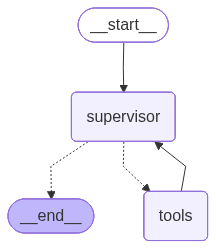

In [15]:

# ==============================================================================
# Step 6: Build and Compile the Graph
# ==============================================================================

builder = StateGraph(SupervisorState)

# Add Nodes
builder.add_node("supervisor", supervisor_agent)
builder.add_node("tools", tool_node)

# Add Edges
builder.add_edge(START, "supervisor")

# Conditional edge after supervisor node execution
builder.add_conditional_edges(
    "supervisor",
    should_continue,
    {
        "tools": "tools",
        END: END
    }
)

# After running tools, always loop back to the supervisor
builder.add_edge("tools", "supervisor")

# Compile
workflow = builder.compile()
workflow 


In [ ]:


# ==============================================================================
# Step 7: Run the Supervisor
# ==============================================================================

if __name__ == "__main__":
    print("\n" + "=" * 60)
    print("🚀 SUPERVISOR AS TOOLS PIPELINE — Starting")
    print("=" * 60)
    
    # Query requiring sequential research and formatting
    user_query = (
        "Write a structured 2-paragraph report comparing the current stock performance "
        "and market capitalizations of Apple and Microsoft in 2026. Use the research sub-agent "
        "to gather data, and the writing sub-agent to format it professionally."
    )
    
    result = workflow.invoke({
        "messages": [HumanMessage(content=user_query)]
    })
    
    print("\n" + "=" * 80)
    print("🎯 FINAL CONVERSATION OUTPUT")
    print("=" * 80)
    
    # Find the final text message in the conversation history
    for msg in reversed(result["messages"]):
        if msg.content and not hasattr(msg, "tool_calls") and msg.__class__.__name__ != "ToolMessage":
            print(f"[{msg.__class__.__name__}]:\n\n{msg.content}\n")
            break
            
    print("=" * 80)


🚀 SUPERVISOR AS TOOLS PIPELINE — Starting

🧠 [Supervisor] Evaluating current state...
🔗 [Supervisor] Delegating to Sub-Agent tool: 'research_sub_agent_tool'
🔍 [Research Agent] Researching query: 'Apple stock performance 2026'...
🔍 [Research Agent] Researching query: 'Microsoft stock performance 2026'...
🔍 [Research Agent] Researching query: 'Apple market capitalization 2026'...
🔍 [Research Agent] Researching query: 'Microsoft market capitalization 2026'...
✍️  [Writing Agent] Formatting and organizing notes...

🧠 [Supervisor] Evaluating current state...
🔗 [Supervisor] Delegating to Sub-Agent tool: 'writing_sub_agent_tool'
✍️  [Writing Agent] Formatting and organizing notes...

🧠 [Supervisor] Evaluating current state...
🔗 [Supervisor] Delegating to Sub-Agent tool: 'writing_sub_agent_tool'
✍️  [Writing Agent] Formatting and organizing notes...

🧠 [Supervisor] Evaluating current state...
🔗 [Supervisor] Delegating to Sub-Agent tool: 'writing_sub_agent_tool'
✍️  [Writing Agent] Formatting 